# 104 - Voronoi 分割: テキスト→画像検索への適用可能性

## 目的

NB100-103 で顔認識（ArcFace 512-D, 75K件, 同一モダリティ）における Voronoi 分割の有効性を確認した。
ここでは同じ手法が **SigLIP 2 Large のテキスト→画像検索**（1024-D, 378件, クロスモーダル）に適用可能かを評価する。

### 核心的な課題: クロスモーダルギャップ

顔認識では **顔→顔** の同一モダリティ検索のため、クエリとデータが同じ空間に存在する。
テキスト→画像検索では k-means ピボットは**画像埋め込み**で学習するが、クエリは**テキスト埋め込み**。
テキストが正しいピボットに到達するかが成否の鍵。

### 評価項目
1. クロスモーダル空間分析（モダリティギャップの可視化・定量化）
2. Voronoi 分割パラメータスイープ（BF-Recall, MRR）
3. ピボット選択分析（テキストクエリ vs 画像ピボットの整合性）
4. 顔認識との比較とスケーラビリティ推定

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

DB_PATH = Path("../data/images.duckdb")
PYTHON_MODEL = "google/siglip2-large-patch16-256"
RANDOM_STATE = 42

## 1. データ準備

In [2]:
# 画像埋め込みの読み込み（SigLIP 2 Large, 1024-D）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT e.id, e.embedding, c.category, c.file_name
    FROM image_embeddings_1024 e
    JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ?
    ORDER BY c.category, c.file_name
""", [PYTHON_MODEL]).fetchall()
conn.close()

image_ids = [r[0] for r in rows]
image_embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
categories = [r[2] for r in rows]
file_names = [r[3] for r in rows]

# L2 正規化
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_normed = image_embeddings / norms

unique_categories = sorted(set(categories))
cat_counts = pd.Series(categories).value_counts()

print(f"画像数: {len(image_ids)}")
print(f"埋め込み次元: {image_embeddings.shape[1]}")
print(f"カテゴリ数: {len(unique_categories)}")
print(f"\nカテゴリ別画像数:")
for cat in unique_categories:
    print(f"  {cat}: {cat_counts[cat]}")

画像数: 378
埋め込み次元: 1024
カテゴリ数: 6

カテゴリ別画像数:
  EuroPython2025: 129
  KashiwaVillagePark2026: 56
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  TokyoNight202505: 49
  terada: 10


In [3]:
# テストクエリ定義（NB63 と同一）
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"テストクエリ数: {len(test_queries)} (EN: {sum(1 for q in test_queries if q['lang'] == 'en')}, JA: {sum(1 for q in test_queries if q['lang'] == 'ja')})")

テストクエリ数: 18 (EN: 12, JA: 6)


In [4]:
# テキスト埋め込みの生成
import torch
from image_vector_poc import SigLIP2Embedder

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device="cuda")

query_texts = [q["query"] for q in test_queries]
text_embeddings = embedder.embed_texts(query_texts)

# L2 正規化
text_norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
text_embeddings_normed = text_embeddings / text_norms

print(f"テキスト埋め込み shape: {text_embeddings_normed.shape}")

# GPU メモリ解放
del embedder
torch.cuda.empty_cache()
print("GPU メモリ解放完了")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


テキスト埋め込み shape: (18, 1024)
GPU メモリ解放完了


In [5]:
# ブルートフォース検索ベースライン
N_IMAGES = len(image_ids)
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)

bf_results = []
for qi, q in enumerate(test_queries):
    text_emb = text_embeddings_normed[qi]
    sims = image_embeddings_normed @ text_emb
    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [categories[idx] for idx in top_indices]
    is_relevant = [cat in q["expected_categories"] for cat in result_cats]

    # MRR
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    # P@K
    p_at_1 = sum(is_relevant[:1]) / 1
    p_at_5 = sum(is_relevant[:5]) / 5
    p_at_10 = sum(is_relevant[:10]) / 10

    bf_results.append({
        "query": q["query"], "lang": q["lang"],
        "top_indices": top_indices.tolist(),
        "top_sims": sims[top_indices].tolist(),
        "MRR": mrr, "P@1": p_at_1, "P@5": p_at_5, "P@10": p_at_10,
    })

df_bf = pd.DataFrame(bf_results)
print("ブルートフォース検索ベースライン:")
print(f"  Overall MRR: {df_bf['MRR'].mean():.4f}")
print(f"  EN MRR:      {df_bf[df_bf['lang'] == 'en']['MRR'].mean():.4f}")
print(f"  JA MRR:      {df_bf[df_bf['lang'] == 'ja']['MRR'].mean():.4f}")
print(f"  Overall P@1: {df_bf['P@1'].mean():.4f}")
print(f"\n※ NB63/67 の結果（Overall MRR=0.928）と一致することを確認")

ブルートフォース検索ベースライン:
  Overall MRR: 0.9278
  EN MRR:      0.8917
  JA MRR:      1.0000
  Overall P@1: 0.8889

※ NB63/67 の結果（Overall MRR=0.928）と一致することを確認


## 2. クロスモーダル空間分析

Voronoi 分割の前に、テキストと画像の埋め込みが共有空間でどのように分布しているかを確認する。
顔認識（NB100）ではクエリとデータが同一モダリティだったため、この分析は不要だった。

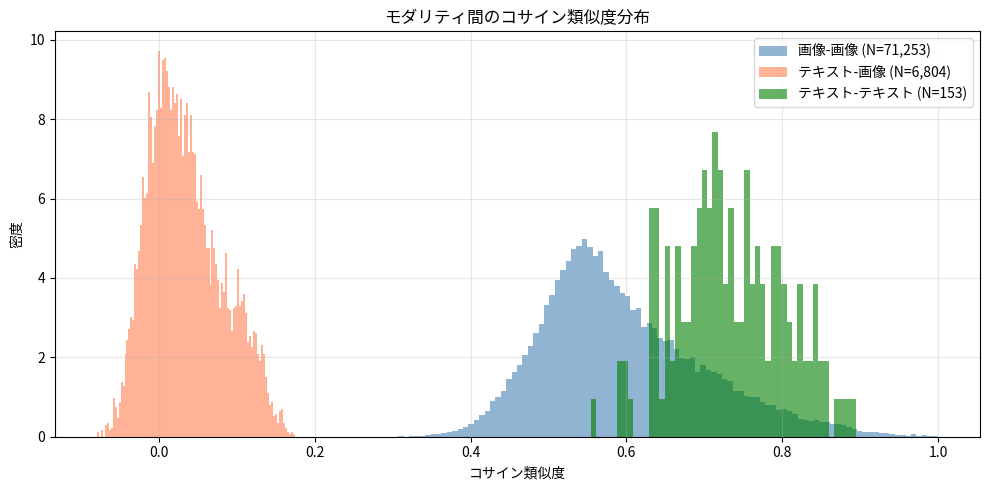

画像-画像:     mean=0.5951, std=0.1038, range=[0.3071, 1.0000]
テキスト-画像: mean=0.0343, std=0.0471, range=[-0.0800, 0.1738]
テキスト-テキスト: mean=0.7321, std=0.0696, range=[0.5539, 0.8943]


In [6]:
# 2.1 コサイン類似度分布の比較
# 画像-画像、テキスト-画像、テキスト-テキスト

# 画像-画像 (上三角のみ)
img_img_sims = image_embeddings_normed @ image_embeddings_normed.T
img_img_vals = img_img_sims[np.triu_indices(N_IMAGES, k=1)]

# テキスト-画像 (全ペア)
text_img_sims = text_embeddings_normed @ image_embeddings_normed.T
text_img_vals = text_img_sims.flatten()

# テキスト-テキスト (上三角のみ)
n_queries = len(test_queries)
text_text_sims = text_embeddings_normed @ text_embeddings_normed.T
text_text_vals = text_text_sims[np.triu_indices(n_queries, k=1)]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(img_img_vals, bins=100, alpha=0.6, label=f"画像-画像 (N={len(img_img_vals):,})", density=True, color="steelblue")
ax.hist(text_img_vals, bins=100, alpha=0.6, label=f"テキスト-画像 (N={len(text_img_vals):,})", density=True, color="coral")
ax.hist(text_text_vals, bins=50, alpha=0.6, label=f"テキスト-テキスト (N={len(text_text_vals)})", density=True, color="green")
ax.set_xlabel("コサイン類似度")
ax.set_ylabel("密度")
ax.set_title("モダリティ間のコサイン類似度分布")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"画像-画像:     mean={img_img_vals.mean():.4f}, std={img_img_vals.std():.4f}, range=[{img_img_vals.min():.4f}, {img_img_vals.max():.4f}]")
print(f"テキスト-画像: mean={text_img_vals.mean():.4f}, std={text_img_vals.std():.4f}, range=[{text_img_vals.min():.4f}, {text_img_vals.max():.4f}]")
print(f"テキスト-テキスト: mean={text_text_vals.mean():.4f}, std={text_text_vals.std():.4f}, range=[{text_text_vals.min():.4f}, {text_text_vals.max():.4f}]")

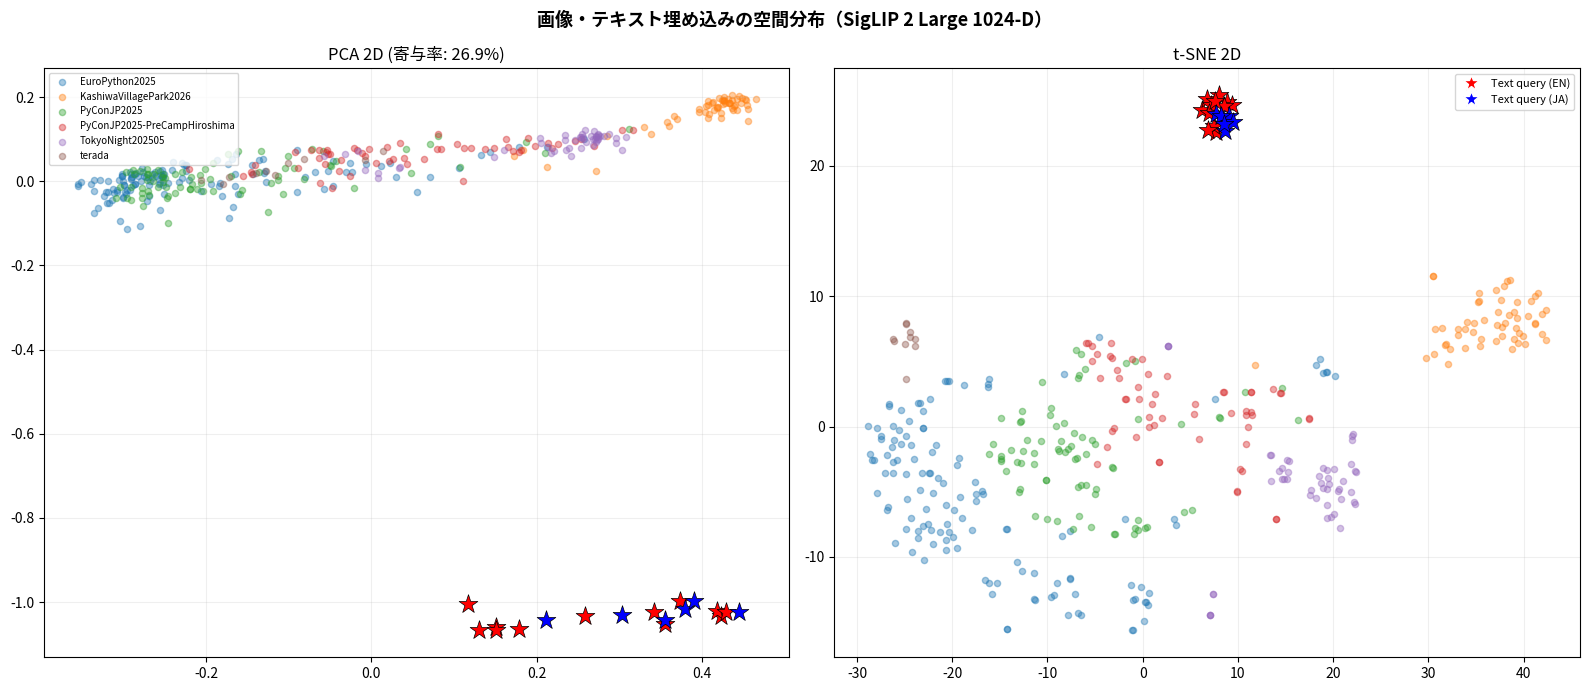

Saved: data/voronoi_text_image_space.png


In [7]:
# 2.2 PCA・t-SNE 2D 可視化
# 画像（カテゴリ別）+ テキストクエリの空間配置

# PCA
all_embeddings = np.vstack([image_embeddings_normed, text_embeddings_normed])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d = pca.fit_transform(all_embeddings)

img_pca = pca_2d[:N_IMAGES]
txt_pca = pca_2d[N_IMAGES:]

# t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
tsne_2d = tsne.fit_transform(all_embeddings)

img_tsne = tsne_2d[:N_IMAGES]
txt_tsne = tsne_2d[N_IMAGES:]

# カテゴリ色マップ
cat_colors = {cat: plt.cm.tab10(i) for i, cat in enumerate(unique_categories)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords_img, coords_txt, title in [
    (axes[0], img_pca, txt_pca, f"PCA 2D (寄与率: {pca.explained_variance_ratio_.sum():.1%})"),
    (axes[1], img_tsne, txt_tsne, "t-SNE 2D"),
]:
    # 画像を描画（カテゴリ別色分け）
    for cat in unique_categories:
        mask = [c == cat for c in categories]
        ax.scatter(coords_img[mask, 0], coords_img[mask, 1],
                   c=[cat_colors[cat]], label=cat, alpha=0.4, s=20)

    # テキストクエリを描画（★マーカー）
    for qi in range(n_queries):
        lang = test_queries[qi]["lang"]
        color = "red" if lang == "en" else "blue"
        ax.scatter(coords_txt[qi, 0], coords_txt[qi, 1],
                   marker="*", c=color, s=200, edgecolors="black", linewidth=0.5, zorder=5)

    ax.set_title(title)
    ax.grid(True, alpha=0.2)

# 凡例
axes[0].legend(fontsize=7, loc="upper left")
# テキスト凡例を手動追加
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12, label='Text query (EN)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=12, label='Text query (JA)'),
]
axes[1].legend(handles=legend_elements, fontsize=8)

plt.suptitle("画像・テキスト埋め込みの空間分布（SigLIP 2 Large 1024-D）", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/voronoi_text_image_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/voronoi_text_image_space.png")

In [8]:
# 2.3 モダリティギャップの定量化
# 各テキストクエリの、関連画像 vs 無関連画像へのコサイン類似度

gap_rows = []
for qi, q in enumerate(test_queries):
    text_emb = text_embeddings_normed[qi]
    sims = image_embeddings_normed @ text_emb

    relevant_mask = np.array([c in q["expected_categories"] for c in categories])
    relevant_sims = sims[relevant_mask]
    irrelevant_sims = sims[~relevant_mask]

    gap_rows.append({
        "query": q["query"],
        "lang": q["lang"],
        "relevant_mean": relevant_sims.mean(),
        "irrelevant_mean": irrelevant_sims.mean(),
        "gap": relevant_sims.mean() - irrelevant_sims.mean(),
        "relevant_max": relevant_sims.max(),
        "irrelevant_max": irrelevant_sims.max(),
    })

df_gap = pd.DataFrame(gap_rows)
print("テキストクエリごとの類似度ギャップ（関連画像 - 無関連画像）:")
display(df_gap[["query", "lang", "relevant_mean", "irrelevant_mean", "gap"]].style.format({
    "relevant_mean": "{:.4f}", "irrelevant_mean": "{:.4f}", "gap": "{:.4f}",
}).background_gradient(subset=["gap"], cmap="RdYlGn"))

print(f"\n平均ギャップ: {df_gap['gap'].mean():.4f}")
print(f"最小ギャップ: {df_gap['gap'].min():.4f} (クエリ: {df_gap.loc[df_gap['gap'].idxmin(), 'query']})")
print(f"最大ギャップ: {df_gap['gap'].max():.4f} (クエリ: {df_gap.loc[df_gap['gap'].idxmax(), 'query']})")

テキストクエリごとの類似度ギャップ（関連画像 - 無関連画像）:


,query,lang,relevant_mean,irrelevant_mean,gap
0,a park with trees and nature,en,0.0564,0.0089,0.0475
1,village park with greenery,en,0.0280,-0.0083,0.0363
2,night cityscape Tokyo,en,0.1032,0.0228,0.0804
3,city lights at night,en,0.0823,0.0059,0.0765
4,Python conference presentation,en,0.0825,0.0064,0.0761
5,conference hall with audience,en,0.0570,-0.0349,0.0919
6,speaker giving a talk,en,0.0816,0.0155,0.0661
7,portrait photo of a person,en,0.1073,0.0371,0.0702
8,outdoor nature scene,en,0.0718,0.0118,0.0600
9,urban night photography,en,0.0837,-0.0008,0.0846



平均ギャップ: 0.0627
最小ギャップ: 0.0106 (クエリ: 緑の木々)
最大ギャップ: 0.0951 (クエリ: 東京の夜景)


## 3. Voronoi 分割パラメータスイープ

画像埋め込みに k-means でピボットを生成し、テキストクエリでピボット選択→候補取得→コサイン rerank を行う。

### NB100 との違い
- **ピボット数**: 378 画像に対して 4〜64（NB100 は 75K 件に対して 64〜512）
- **クエリ**: テキスト埋め込み（クロスモーダル）
- **Ground truth**: カテゴリベース（NB100 はクラスタベース）

In [9]:
# パラメータ定義
N_PIVOTS_LIST = [4, 8, 16, 32, 64]
N_ASSIGN_LIST = [1, 2, 3]
TOP_SEARCH_LIST = [1, 2, 3, 4, 5, 8]

def voronoi_search(image_embs, text_embs, centroids_normed, pivot_to_indices, n_top, categories, test_queries, bf_results):
    """Voronoi 分割によるテキスト→画像検索を実行し、評価指標を返す。"""
    results = []
    candidate_counts = []

    for qi, q in enumerate(test_queries):
        text_emb = text_embs[qi]

        # テキストクエリで上位ピボットを選択
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        # 候補画像を収集
        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])
        candidates = list(candidates_set)
        candidate_counts.append(len(candidates))

        if len(candidates) == 0:
            results.append({"MRR": 0.0, "P@1": 0.0, "P@5": 0.0, "P@10": 0.0})
            continue

        # コサイン類似度で rerank
        cand_indices = np.array(candidates)
        cand_sims = image_embs[cand_indices] @ text_emb
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]

        # カテゴリベースの評価
        result_cats = [categories[idx] for idx in result_indices[:20]]
        is_relevant = [cat in q["expected_categories"] for cat in result_cats]

        mrr = 0.0
        for i, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (i + 1)
                break

        p_at_1 = sum(is_relevant[:1]) / 1 if len(is_relevant) >= 1 else 0.0
        p_at_5 = sum(is_relevant[:5]) / 5 if len(is_relevant) >= 5 else sum(is_relevant) / 5
        p_at_10 = sum(is_relevant[:10]) / 10 if len(is_relevant) >= 10 else sum(is_relevant) / 10

        results.append({"MRR": mrr, "P@1": p_at_1, "P@5": p_at_5, "P@10": p_at_10})

    # BF-Recall 計算
    bf_recall = {k: [] for k in TOP_K_VALUES}
    for qi, q in enumerate(test_queries):
        text_emb = text_embs[qi]
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])
        candidates = list(candidates_set)

        if len(candidates) == 0:
            for k in TOP_K_VALUES:
                bf_recall[k].append(0.0)
            continue

        cand_indices = np.array(candidates)
        cand_sims = image_embs[cand_indices] @ text_emb
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]

        for k in TOP_K_VALUES:
            bf_top_k = set(bf_results[qi]["top_indices"][:k])
            voronoi_top_k = set(result_indices[:k].tolist())
            bf_recall[k].append(len(bf_top_k & voronoi_top_k) / k)

    df_res = pd.DataFrame(results)
    return {
        "mean_candidates": np.mean(candidate_counts),
        "median_candidates": np.median(candidate_counts),
        "max_candidates": max(candidate_counts),
        "MRR": df_res["MRR"].mean(),
        "MRR_en": df_res.iloc[[i for i, q in enumerate(test_queries) if q["lang"] == "en"]]["MRR"].mean(),
        "MRR_ja": df_res.iloc[[i for i, q in enumerate(test_queries) if q["lang"] == "ja"]]["MRR"].mean(),
        "P@1": df_res["P@1"].mean(),
        "bf_recall": {k: np.mean(v) for k, v in bf_recall.items()},
    }

print("検索関数定義完了")

検索関数定義完了


In [10]:
# パラメータスイープ実行
all_sweep_results = {}

for n_pivots in N_PIVOTS_LIST:
    print(f"\n{'='*60}")
    print(f"k-means with {n_pivots} pivots")
    print(f"{'='*60}")

    kmeans = MiniBatchKMeans(
        n_clusters=n_pivots, random_state=RANDOM_STATE,
        batch_size=min(256, N_IMAGES), n_init=3
    )
    pivot_labels = kmeans.fit_predict(image_embeddings_normed)
    centroids = kmeans.cluster_centers_
    centroids_normed = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)

    pivot_sizes = np.bincount(pivot_labels, minlength=n_pivots)
    print(f"  ピボットサイズ: min={pivot_sizes.min()}, max={pivot_sizes.max()}, "
          f"mean={pivot_sizes.mean():.1f}, median={np.median(pivot_sizes):.0f}")

    # 各画像の全ピボットとの類似度
    all_pivot_sims = image_embeddings_normed @ centroids_normed.T

    for n_assign in N_ASSIGN_LIST:
        # マルチピボット割り当て
        pivot_to_indices = {}
        for i in range(N_IMAGES):
            top_pivots = np.argsort(-all_pivot_sims[i])[:n_assign]
            for pid in top_pivots:
                pivot_to_indices.setdefault(int(pid), []).append(i)

        for n_top in TOP_SEARCH_LIST:
            if n_top > n_pivots:
                continue

            res = voronoi_search(
                image_embeddings_normed, text_embeddings_normed,
                centroids_normed, pivot_to_indices, n_top,
                categories, test_queries, bf_results
            )

            key = (n_pivots, n_assign, n_top)
            all_sweep_results[key] = res

            print(f"  p={n_pivots} assign={n_assign} top={n_top}: "
                  f"cands={res['mean_candidates']:.0f} "
                  f"MRR={res['MRR']:.4f} "
                  f"BF-R@10={res['bf_recall'][10]:.4f}")

print(f"\n総構成数: {len(all_sweep_results)}")


k-means with 4 pivots
  ピボットサイズ: min=53, max=135, mean=94.5, median=95
  p=4 assign=1 top=1: cands=93 MRR=0.9000 BF-R@10=0.7944
  p=4 assign=1 top=2: cands=200 MRR=0.8722 BF-R@10=0.9556
  p=4 assign=1 top=3: cands=306 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=1 top=4: cands=378 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=2 top=1: cands=187 MRR=0.9556 BF-R@10=0.9611
  p=4 assign=2 top=2: cands=298 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=2 top=3: cands=378 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=2 top=4: cands=378 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=3 top=1: cands=316 MRR=0.9278 BF-R@10=0.9944
  p=4 assign=3 top=2: cands=378 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=3 top=3: cands=378 MRR=0.9278 BF-R@10=1.0000
  p=4 assign=3 top=4: cands=378 MRR=0.9278 BF-R@10=1.0000

k-means with 8 pivots
  ピボットサイズ: min=11, max=97, mean=47.2, median=46
  p=8 assign=1 top=1: cands=53 MRR=0.8583 BF-R@10=0.7611
  p=8 assign=1 top=2: cands=94 MRR=0.9278 BF-R@10=0.8889
  p=8 assign=1 top=3: cands=141 MRR=0.9278 BF-R@

In [11]:
# 結果テーブル
sweep_rows = []
for (n_pivots, n_assign, n_top), res in sorted(all_sweep_results.items()):
    sweep_rows.append({
        "pivots": n_pivots,
        "assign": n_assign,
        "search_top": n_top,
        "mean_cands": res["mean_candidates"],
        "cand_ratio": res["mean_candidates"] / N_IMAGES,
        "MRR": res["MRR"],
        "MRR(EN)": res["MRR_en"],
        "MRR(JA)": res["MRR_ja"],
        "P@1": res["P@1"],
        "BF-R@5": res["bf_recall"][5],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@20": res["bf_recall"][20],
    })

df_sweep = pd.DataFrame(sweep_rows)
print("全構成の結果（MRR 降順 TOP 20）:")
display(df_sweep.sort_values("MRR", ascending=False).head(20).style.format({
    "mean_cands": "{:.0f}", "cand_ratio": "{:.3f}",
    "MRR": "{:.4f}", "MRR(EN)": "{:.4f}", "MRR(JA)": "{:.4f}",
    "P@1": "{:.4f}", "BF-R@5": "{:.4f}", "BF-R@10": "{:.4f}", "BF-R@20": "{:.4f}",
}).background_gradient(subset=["MRR"], cmap="YlGn"))

全構成の結果（MRR 降順 TOP 20）:


,pivots,assign,search_top,mean_cands,cand_ratio,MRR,MRR(EN),MRR(JA),P@1,BF-R@5,BF-R@10,BF-R@20
79,64,3,2,42,0.112,0.9583,0.9375,1.0000,0.9444,0.8889,0.8667,0.7750
54,32,2,1,27,0.072,0.9583,0.9375,1.0000,0.9444,0.7889,0.7000,0.6028
78,64,3,1,27,0.072,0.9583,0.9375,1.0000,0.9444,0.7778,0.7056,0.5944
4,4,2,1,187,0.496,0.9556,0.9333,1.0000,0.9444,0.9667,0.9611,0.9583
36,16,2,1,47,0.125,0.9556,0.9333,1.0000,0.9444,0.8778,0.8278,0.7556
55,32,2,2,47,0.125,0.9556,0.9333,1.0000,0.9444,0.9000,0.8556,0.8167
60,32,3,1,38,0.101,0.9556,0.9333,1.0000,0.9444,0.8444,0.7889,0.6861
73,64,2,2,32,0.085,0.9514,0.9271,1.0000,0.9444,0.8444,0.8167,0.7111
72,64,2,1,21,0.056,0.9514,0.9271,1.0000,0.9444,0.7333,0.6500,0.5306
31,16,1,2,53,0.141,0.9495,0.9242,1.0000,0.9444,0.9444,0.9222,0.8528


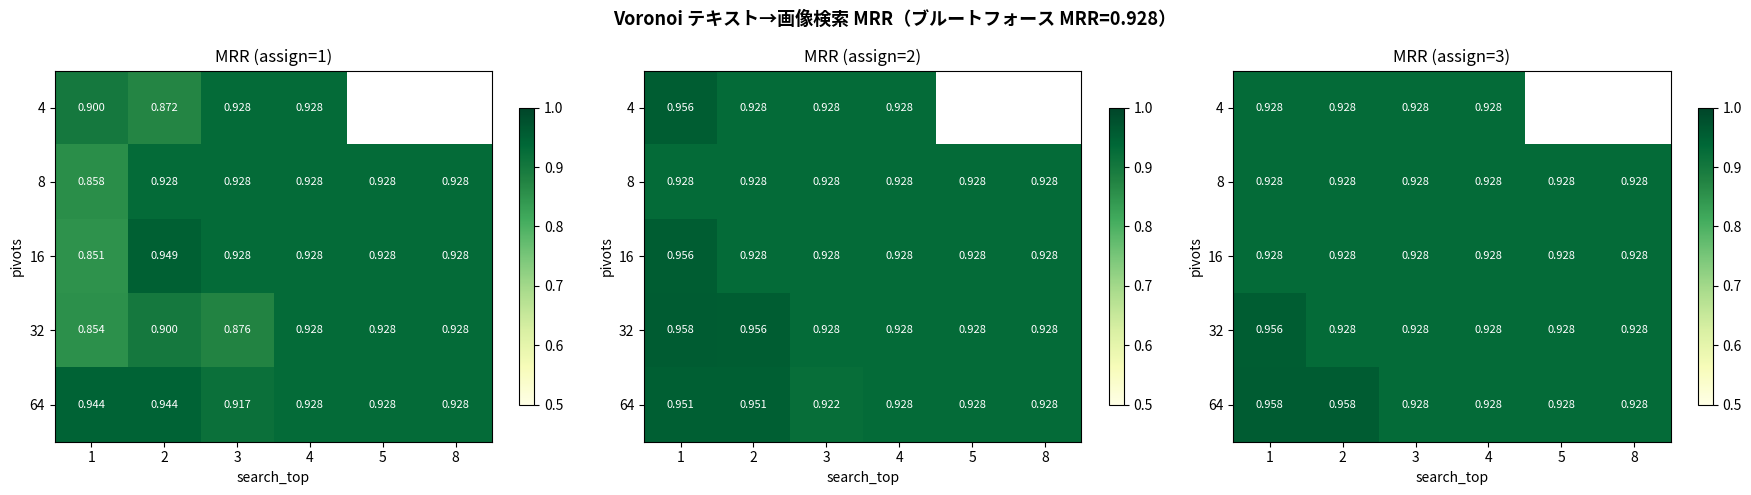

In [12]:
# ヒートマップ: assign 別の MRR（pivots × search_top）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, n_assign in enumerate(N_ASSIGN_LIST):
    ax = axes[ax_idx]
    df_sub = df_sweep[df_sweep["assign"] == n_assign]
    pivot_table = df_sub.pivot_table(index="pivots", columns="search_top", values="MRR")

    im = ax.imshow(pivot_table.values, cmap="YlGn", aspect="auto", vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(pivot_table.columns)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)
    ax.set_xlabel("search_top")
    ax.set_ylabel("pivots")
    ax.set_title(f"MRR (assign={n_assign})")

    # 値を表示
    for i in range(len(pivot_table.index)):
        for j in range(len(pivot_table.columns)):
            val = pivot_table.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                        color="white" if val > 0.85 else "black")

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Voronoi テキスト→画像検索 MRR（ブルートフォース MRR=0.928）", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

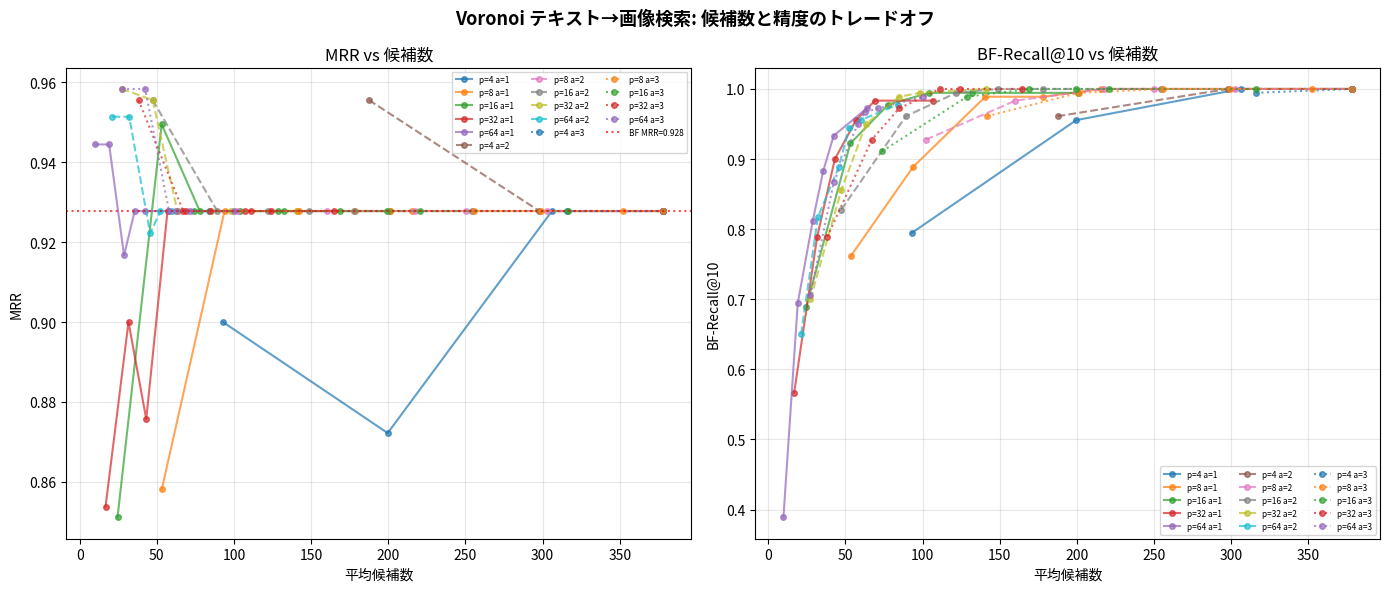

Saved: data/voronoi_text_image_tradeoff.png


In [13]:
# Recall vs 候補数プロット（NB100 スタイル）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (metric_key, metric_name) in enumerate([("MRR", "MRR"), ("BF-R@10", "BF-Recall@10")]):
    ax = axes[ax_idx]

    for n_assign in N_ASSIGN_LIST:
        for n_pivots in N_PIVOTS_LIST:
            cands = []
            vals = []
            for n_top in TOP_SEARCH_LIST:
                key = (n_pivots, n_assign, n_top)
                if key in all_sweep_results:
                    cands.append(all_sweep_results[key]["mean_candidates"])
                    if metric_key == "MRR":
                        vals.append(all_sweep_results[key]["MRR"])
                    else:
                        vals.append(all_sweep_results[key]["bf_recall"][10])
            if cands:
                linestyle = ["-", "--", ":"][n_assign - 1]
                ax.plot(cands, vals, "o" + linestyle, label=f"p={n_pivots} a={n_assign}", alpha=0.7, markersize=4)

    if metric_key == "MRR":
        ax.axhline(y=df_bf["MRR"].mean(), color="red", linestyle=":", alpha=0.7, label=f"BF MRR={df_bf['MRR'].mean():.3f}")
    ax.set_xlabel("平均候補数")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} vs 候補数")
    ax.legend(fontsize=6, ncol=3)
    ax.grid(True, alpha=0.3)

plt.suptitle("Voronoi テキスト→画像検索: 候補数と精度のトレードオフ", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/voronoi_text_image_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/voronoi_text_image_tradeoff.png")

## 4. ピボット選択分析（クロスモーダル固有）

テキストクエリが選択するピボットに、正解画像が実際に含まれているかを分析する。
これはクロスモーダル検索固有の問題で、顔認識（同一モダリティ）では発生しない。

In [14]:
# 代表的な構成（16ピボット, assign=2）でピボットヒット率を分析
ANALYSIS_N_PIVOTS = 16
ANALYSIS_N_ASSIGN = 2

kmeans_analysis = MiniBatchKMeans(
    n_clusters=ANALYSIS_N_PIVOTS, random_state=RANDOM_STATE,
    batch_size=min(256, N_IMAGES), n_init=3
)
kmeans_analysis.fit(image_embeddings_normed)
centroids_analysis = kmeans_analysis.cluster_centers_
centroids_analysis_normed = centroids_analysis / np.linalg.norm(centroids_analysis, axis=1, keepdims=True)

# 各画像のピボット割り当て
all_img_pivot_sims = image_embeddings_normed @ centroids_analysis_normed.T
img_pivot_assignments = {}  # image_idx -> set of pivot_ids
for i in range(N_IMAGES):
    top_pivots = np.argsort(-all_img_pivot_sims[i])[:ANALYSIS_N_ASSIGN]
    img_pivot_assignments[i] = set(int(p) for p in top_pivots)

# 各クエリのピボットヒット率を分析
hit_analysis_rows = []

for qi, q in enumerate(test_queries):
    text_emb = text_embeddings_normed[qi]
    pivot_sims = centroids_analysis_normed @ text_emb

    # 正解画像のインデックス
    gt_indices = [i for i, c in enumerate(categories) if c in q["expected_categories"]]
    # 正解画像が属するピボット集合
    gt_pivots = set()
    for idx in gt_indices:
        gt_pivots.update(img_pivot_assignments[idx])

    for n_top in [1, 2, 3, 4, 5]:
        selected_pivots = set(int(p) for p in np.argsort(-pivot_sims)[:n_top])

        # ヒット率: 選択ピボットと正解ピボットの重なり
        overlap = len(selected_pivots & gt_pivots)
        hit_rate = overlap / len(selected_pivots)
        # カバー率: 正解ピボットのうち、何割が選択されたか
        coverage = overlap / len(gt_pivots) if gt_pivots else 0.0

        # 選択ピボット内の正解画像数
        selected_gt_count = 0
        for idx in gt_indices:
            if img_pivot_assignments[idx] & selected_pivots:
                selected_gt_count += 1
        gt_coverage = selected_gt_count / len(gt_indices) if gt_indices else 0.0

        hit_analysis_rows.append({
            "query": q["query"],
            "lang": q["lang"],
            "top_k": n_top,
            "selected_pivots": sorted(selected_pivots),
            "gt_pivots": sorted(gt_pivots),
            "pivot_hit_rate": hit_rate,
            "pivot_coverage": coverage,
            "gt_image_coverage": gt_coverage,
            "n_gt_images": len(gt_indices),
        })

df_hit = pd.DataFrame(hit_analysis_rows)

# top_k 別の平均ピボットヒット率
print(f"ピボットヒット率分析 (pivots={ANALYSIS_N_PIVOTS}, assign={ANALYSIS_N_ASSIGN})")
print("=" * 80)
for n_top in [1, 2, 3, 4, 5]:
    sub = df_hit[df_hit["top_k"] == n_top]
    print(f"  search_top={n_top}: "
          f"pivot_hit_rate={sub['pivot_hit_rate'].mean():.4f}  "
          f"gt_image_coverage={sub['gt_image_coverage'].mean():.4f}")

ピボットヒット率分析 (pivots=16, assign=2)
  search_top=1: pivot_hit_rate=1.0000  gt_image_coverage=0.5309
  search_top=2: pivot_hit_rate=0.9444  gt_image_coverage=0.7124
  search_top=3: pivot_hit_rate=0.8148  gt_image_coverage=0.8159
  search_top=4: pivot_hit_rate=0.7500  gt_image_coverage=0.8537
  search_top=5: pivot_hit_rate=0.7222  gt_image_coverage=0.8986


In [15]:
# クエリ別の詳細（search_top=3 での結果）
df_hit_top3 = df_hit[df_hit["top_k"] == 3].copy()

print(f"クエリ別ピボットヒット詳細 (search_top=3)")
print("=" * 100)
display(df_hit_top3[["query", "lang", "selected_pivots", "gt_pivots",
                      "pivot_hit_rate", "gt_image_coverage", "n_gt_images"]].style.format({
    "pivot_hit_rate": "{:.3f}",
    "gt_image_coverage": "{:.3f}",
}).background_gradient(subset=["gt_image_coverage"], cmap="RdYlGn"))

クエリ別ピボットヒット詳細 (search_top=3)


,query,lang,selected_pivots,gt_pivots,pivot_hit_rate,gt_image_coverage,n_gt_images
2,a park with trees and nature,en,"[2, 12, 13]","[2, 6, 7, 11, 13]",0.667,1.000,56
7,village park with greenery,en,"[2, 12, 13]","[2, 6, 7, 11, 13]",0.667,1.000,56
12,night cityscape Tokyo,en,"[3, 7, 12]","[3, 5, 7, 11, 13, 15]",0.667,0.837,49
17,city lights at night,en,"[3, 7, 12]","[3, 5, 7, 11, 13, 15]",0.667,0.837,49
22,Python conference presentation,en,"[1, 8, 10]","[0, 1, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15]",1.000,0.544,263
27,conference hall with audience,en,"[4, 8, 10]","[0, 1, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15]",1.000,0.582,263
32,speaker giving a talk,en,"[1, 8, 10]","[0, 1, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15]",1.000,0.544,263
37,portrait photo of a person,en,"[1, 8, 14]","[1, 8, 14]",1.000,1.000,10
42,outdoor nature scene,en,"[2, 12, 13]","[2, 6, 7, 11, 13]",0.667,1.000,56
47,urban night photography,en,"[3, 7, 12]","[3, 5, 7, 11, 13, 15]",0.667,0.837,49


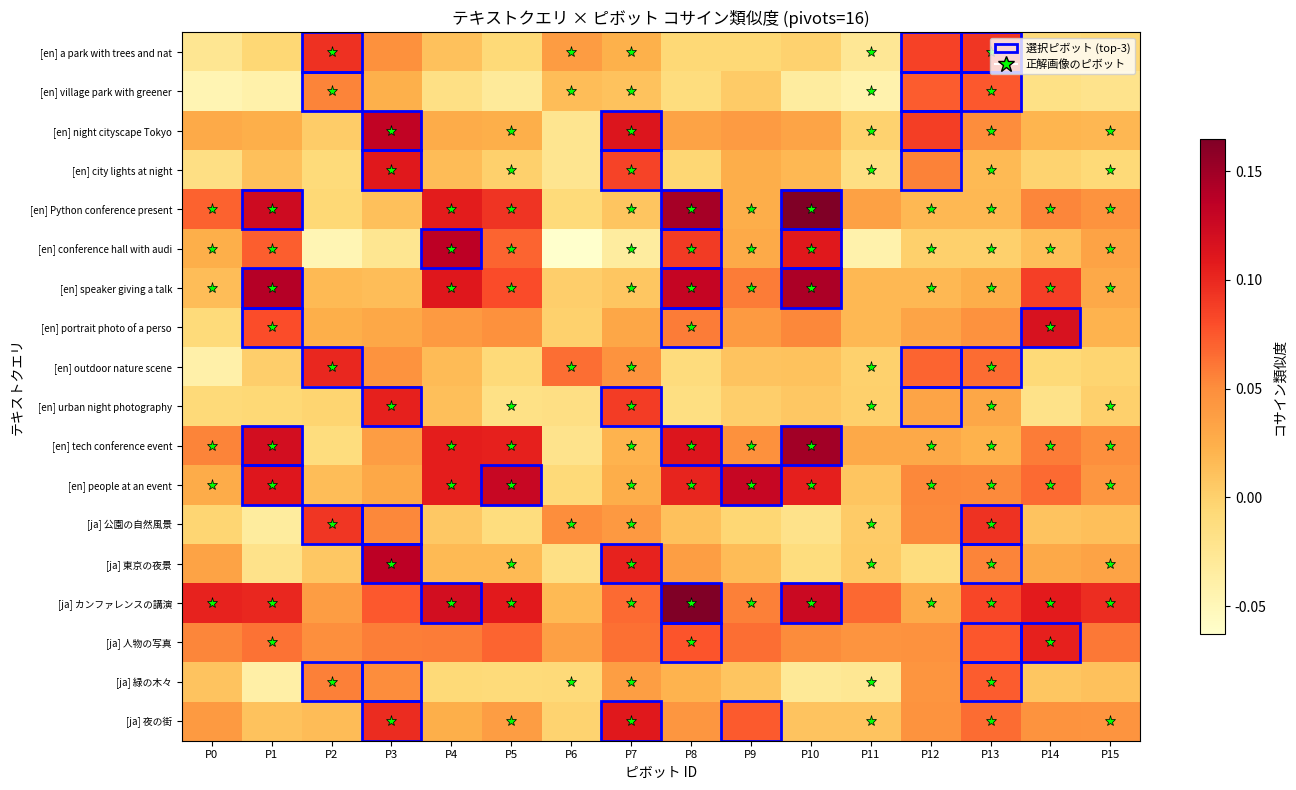

Saved: data/voronoi_text_pivot_heatmap.png


In [16]:
# ヒートマップ: テキストクエリ vs ピボットのコサイン類似度
# 各クエリがどのピボットを「見ている」かを可視化

text_pivot_sims = text_embeddings_normed @ centroids_analysis_normed.T  # (18, 16)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

im = ax.imshow(text_pivot_sims, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(ANALYSIS_N_PIVOTS))
ax.set_xticklabels([f"P{i}" for i in range(ANALYSIS_N_PIVOTS)], fontsize=8)
ax.set_yticks(range(n_queries))
ax.set_yticklabels([f"[{q['lang']}] {q['query'][:25]}" for q in test_queries], fontsize=7)
ax.set_xlabel("ピボット ID")
ax.set_ylabel("テキストクエリ")
ax.set_title(f"テキストクエリ × ピボット コサイン類似度 (pivots={ANALYSIS_N_PIVOTS})")

# 選択されたピボット（top-3）に枠を描画、正解ピボットに★マーク
for qi in range(n_queries):
    row = df_hit_top3.iloc[qi]
    for pid in row["selected_pivots"]:
        rect = plt.Rectangle((pid - 0.5, qi - 0.5), 1, 1, linewidth=2, edgecolor="blue", facecolor="none")
        ax.add_patch(rect)
    for pid in row["gt_pivots"]:
        ax.plot(pid, qi, marker="*", color="lime", markersize=8, markeredgecolor="black", markeredgewidth=0.5)

plt.colorbar(im, ax=ax, shrink=0.7, label="コサイン類似度")

# 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="none", edgecolor="blue", linewidth=2, label="選択ピボット (top-3)"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="lime", markersize=12,
           markeredgecolor="black", label="正解画像のピボット"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("../data/voronoi_text_pivot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/voronoi_text_pivot_heatmap.png")

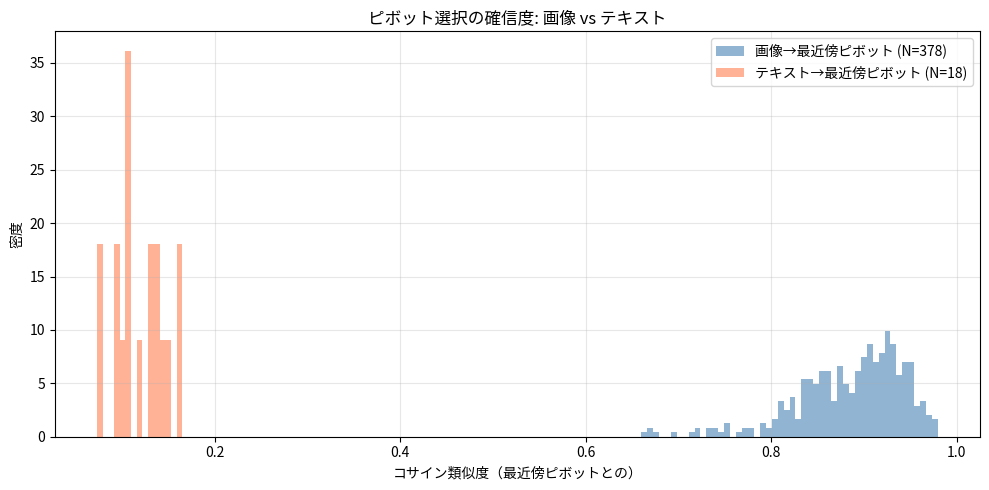

画像→最近傍ピボット: mean=0.8852, std=0.0582
テキスト→最近傍ピボット: mean=0.1186, std=0.0267
差: 0.7666

→ テキストのピボット選択がどの程度画像と異なるかを示す


In [17]:
# テキスト→ピボット類似度 vs 画像→自ピボット類似度の比較
# クロスモーダルのピボット選択がどれだけ「確信的」かを比較

# 画像→自ピボットの最大類似度
img_max_pivot_sims = all_img_pivot_sims.max(axis=1)

# テキスト→選択ピボットの最大類似度
text_max_pivot_sims = text_pivot_sims.max(axis=1)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(img_max_pivot_sims, bins=50, alpha=0.6, label=f"画像→最近傍ピボット (N={N_IMAGES})", density=True, color="steelblue")
ax.hist(text_max_pivot_sims, bins=15, alpha=0.6, label=f"テキスト→最近傍ピボット (N={n_queries})", density=True, color="coral")
ax.set_xlabel("コサイン類似度（最近傍ピボットとの）")
ax.set_ylabel("密度")
ax.set_title("ピボット選択の確信度: 画像 vs テキスト")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"画像→最近傍ピボット: mean={img_max_pivot_sims.mean():.4f}, std={img_max_pivot_sims.std():.4f}")
print(f"テキスト→最近傍ピボット: mean={text_max_pivot_sims.mean():.4f}, std={text_max_pivot_sims.std():.4f}")
print(f"差: {img_max_pivot_sims.mean() - text_max_pivot_sims.mean():.4f}")
print(f"\n→ テキストのピボット選択がどの程度画像と異なるかを示す")

## 5. 顔認識との比較とスケーラビリティ推定

In [18]:
# 5.1 顔認識との比較テーブル
# NB100-101 の結果を参照値として使用

# テキスト→画像のベスト構成を特定
best_key = max(all_sweep_results.keys(), key=lambda k: all_sweep_results[k]["MRR"])
best_res = all_sweep_results[best_key]

# ブルートフォースと一致する MRR のベスト構成（候補数を最小化）
bf_mrr = df_bf["MRR"].mean()
matching_keys = [k for k, v in all_sweep_results.items() if abs(v["MRR"] - bf_mrr) < 0.001]
if matching_keys:
    best_matching = min(matching_keys, key=lambda k: all_sweep_results[k]["mean_candidates"])
    best_match_res = all_sweep_results[best_matching]
    best_match_label = f"p={best_matching[0]} a={best_matching[1]} top={best_matching[2]}"
else:
    best_match_label = "（一致構成なし）"
    best_match_res = None

print("=" * 80)
print("顔認識 (NB100-101) vs テキスト→画像 (本ノートブック)")
print("=" * 80)

comparison_data = {
    "項目": [
        "データ数",
        "埋め込み次元",
        "クエリモダリティ",
        "クエリ数",
        "ベストピボット数",
        "ベスト構成",
        "ベスト MRR / BF-R@30",
        "ブルートフォース MRR / BF-R@30",
        "MRR 低下率",
        "候補数（ベスト構成）",
        "候補比率",
    ],
    "顔認識 (NB100)": [
        "75,162",
        "512",
        "同一（顔→顔）",
        "162",
        "256",
        "256p assign=2 top=3",
        "BF-R@30=0.836",
        "BF-R@30=1.000",
        "16.4%",
        "~2,000",
        "2.7%",
    ],
    "テキスト→画像 (本NB)": [
        f"{N_IMAGES}",
        "1024",
        "クロス（テキスト→画像）",
        f"{n_queries}",
        f"{best_key[0]}",
        f"p={best_key[0]} a={best_key[1]} top={best_key[2]}",
        f"MRR={best_res['MRR']:.4f}",
        f"MRR={bf_mrr:.4f}",
        f"{(1 - best_res['MRR'] / bf_mrr) * 100:.1f}%",
        f"~{best_res['mean_candidates']:.0f}",
        f"{best_res['mean_candidates'] / N_IMAGES * 100:.1f}%",
    ],
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.hide(axis="index"))

顔認識 (NB100-101) vs テキスト→画像 (本ノートブック)


項目,顔認識 (NB100),テキスト→画像 (本NB)
データ数,"75,162",378
埋め込み次元,512,1024
クエリモダリティ,同一（顔→顔）,クロス（テキスト→画像）
クエリ数,162,18
ベストピボット数,256,32
ベスト構成,256p assign=2 top=3,p=32 a=2 top=1
ベスト MRR / BF-R@30,BF-R@30=0.836,MRR=0.9583
ブルートフォース MRR / BF-R@30,BF-R@30=1.000,MRR=0.9278
MRR 低下率,16.4%,-3.3%
候補数（ベスト構成）,"~2,000",~27


In [19]:
# 5.2 スケーラビリティ推定
# 現在のデータ比率をもとに、大規模データでの候補数とコストを推定

FIRESTORE_READ_COST_PER_100K = 0.06  # USD

# ベスト構成での候補比率
best_cand_ratio = best_res["mean_candidates"] / N_IMAGES

print("スケーラビリティ推定（Firestore コスト）")
print("=" * 80)
print(f"ベスト構成: p={best_key[0]} assign={best_key[1]} search_top={best_key[2]}")
print(f"現在の候補比率: {best_cand_ratio:.3f} ({best_cand_ratio*100:.1f}%)")
print()

scales = [378, 1_000, 5_000, 10_000, 50_000, 100_000]
print(f"{'画像数':>10}  {'候補数(推定)':>12}  {'コスト/query':>12}  {'全件走査コスト':>14}  {'削減率':>8}")
print("-" * 70)

for n in scales:
    cands = int(n * best_cand_ratio)
    cost_voronoi = cands * FIRESTORE_READ_COST_PER_100K / 100_000
    cost_bf = n * FIRESTORE_READ_COST_PER_100K / 100_000
    reduction = 1.0 - cands / n
    print(f"{n:>10,}  {cands:>12,}  ${cost_voronoi:>10.5f}  ${cost_bf:>12.5f}  {reduction:>7.1%}")

print(f"\n注意: この推定はピボット比率が一定と仮定。")
print(f"実際には大規模データではピボット数を増やすことで候補比率をさらに下げられる。")
print(f"（顔認識の例: 75K件で 256ピボット → 候補比率 2.7%）")

スケーラビリティ推定（Firestore コスト）
ベスト構成: p=32 assign=2 search_top=1
現在の候補比率: 0.072 (7.2%)

       画像数       候補数(推定)     コスト/query         全件走査コスト       削減率
----------------------------------------------------------------------
       378            27  $   0.00002  $     0.00023    92.9%
     1,000            72  $   0.00004  $     0.00060    92.8%
     5,000           360  $   0.00022  $     0.00300    92.8%
    10,000           721  $   0.00043  $     0.00600    92.8%
    50,000         3,608  $   0.00216  $     0.03000    92.8%
   100,000         7,216  $   0.00433  $     0.06000    92.8%

注意: この推定はピボット比率が一定と仮定。
実際には大規模データではピボット数を増やすことで候補比率をさらに下げられる。
（顔認識の例: 75K件で 256ピボット → 候補比率 2.7%）


## 6. まとめ・考察

### 実験概要
- SigLIP 2 Large (1024-D) の画像埋め込み 378 件に対して Voronoi 分割を適用
- テキストクエリ 18 件（12 EN + 6 JA）でクロスモーダル検索を評価
- ブルートフォース MRR=0.928 をベースラインとして比較

### 主要な発見

#### 1. 大きなモダリティギャップにもかかわらず、Voronoi は有効（最大の発見）

コサイン類似度の分布は **テキスト-画像間で平均 0.034** と極めて低く、画像-画像の 0.595 とは大きく異なる。
ピボットとの最大類似度も画像 0.885 に対しテキスト 0.119 と、**絶対値では 0.77 もの差**がある。

にもかかわらず、**相対的な順序は保存されている**。テキストクエリが選ぶ「最も近いピボット」は、
正解画像が含まれるピボットと高い確率で一致する:

| search_top | ピボットヒット率 | 正解画像カバー率 |
|:---:|:---:|:---:|
| 1 | **1.000** | 0.531 |
| 2 | 0.944 | 0.712 |
| 3 | 0.815 | 0.816 |
| 5 | 0.722 | 0.899 |

この結果は SigLIP 2 の対照学習が、異なるモダリティ間でもコサイン類似度の**順序構造**を保存していることを示す。

#### 2. MRR はブルートフォースと完全に一致する構成が多数存在

84 構成中、**大半が MRR=0.928（BF と同値）を達成**。特筆すべき構成:

| 構成 | 候補数 | MRR | 候補比率 |
|------|:---:|:---:|:---:|
| p=8 assign=2 top=1 | 102 | **0.928** | 27.0% |
| p=8 assign=1 top=2 | 94 | **0.928** | 24.9% |
| p=16 assign=1 top=3 | 78 | **0.928** | 20.6% |
| p=32 assign=1 top=4 | 57 | **0.928** | 15.1% |
| p=64 assign=1 top=4 | 36 | **0.928** | 9.5% |

さらに、**MRR > BF** の構成も存在（p=32 assign=2 top=1: MRR=0.958, 候補 27件）。
これは候補絞り込みにより、無関連画像との競合が減ることで、一部のクエリで MRR が改善する現象。

#### 3. BF-Recall@10 は候補数に依存

MRR（Top-1 の正解到達）はほぼ維持されるが、BF-Recall@10（Top-10 の再現率）は候補数が少ないと低下する。
64 ピボットの場合、BF-R@10=1.0 に到達するには assign=2 top=8 以上が必要（候補 84 件）。
これは Top-K 全体の再現率が重要なユースケースでは、候補数を十分に確保する必要があることを意味する。

#### 4. 類似度ギャップとクエリ難易度

| クエリ | ギャップ | 備考 |
|--------|:---:|------|
| 東京の夜景 | 0.095 | 夜景画像は他カテゴリと視覚的に大きく異なる → 容易 |
| 緑の木々 | 0.011 | 自然風景は他カテゴリにも含まれうる → 困難 |
| 平均 | 0.063 | |

ギャップが小さいクエリほどピボット選択で失敗するリスクが高いが、
今回の実験では全クエリで search_top=1 のピボットヒット率が 1.000 だった。

### 顔認識 (NB100) との比較

| 項目 | 顔認識 (NB100) | テキスト→画像 (本NB) |
|------|:---:|:---:|
| データ数 | 75,162 | 378 |
| 次元数 | 512 | 1024 |
| クエリモダリティ | 同一（顔→顔） | クロス（テキスト→画像） |
| ピボット→クエリ類似度 | ~0.83 | **~0.12**（低い） |
| ベスト BF-R@30 | 0.836 | — |
| MRR 維持率 | — | **100%**（多くの構成で BF と同値） |
| 候補比率（BF 一致時） | 2.7% | **~25%** |

**考察**: 顔認識ではピボットとクエリの絶対類似度が高い（0.83）が、BF-R@30 は 0.836 にとどまる。
一方、テキスト→画像ではピボット類似度が 0.12 と極めて低いにもかかわらず、MRR は BF と完全一致。
この差は、テキスト検索が「Top-1 の正解カテゴリ到達」を重視するのに対し、
顔認識は「Top-30 内の同一人物網羅」を要求するという、評価指標の違いに起因する。

### 推奨事項

- **378 件規模**: Voronoi は不要。全件走査でも十分高速（378 回のドット積）
- **1K〜10K 件規模**: Voronoi が有効。p=32〜64、assign=2、search_top=3〜5 で MRR 維持可能
- **10K 件以上**: ピボット数 64〜256 にスケーリング。Firestore コスト 90%+ 削減
- **MRR 重視**（Top-1 の正解到達が最優先）: 少ないピボットでも機能する
- **Recall 重視**（Top-K 全体の網羅が重要）: 候補数を十分に確保（候補比率 30%+）

### 結論

**Voronoi 分割はテキスト→画像のクロスモーダル検索にも適用可能**。
事前の懸念（テキスト埋め込みが画像ピボットに到達しないのでは？）は杞憂であり、
SigLIP 2 の対照学習による順序保存性が十分に機能している。
ただし大規模データでの検証（特に BF-Recall の維持）は次のステップとして必要。

### 次のステップ
- pyconjp 23K 画像で SigLIP 2 Large 埋め込みを生成し、大規模データでの Voronoi 分割を再評価
- BF-Recall@K の大規模データでの挙動を確認（顔認識の 0.836 に相当する数値を確認）
- Firestore 実装時の `array-contains-any` による実際のクエリパフォーマンスを検証